# Question 2: Testing

## Assignment
> Marktplaats has decided on implementing a product feature that we think
will drive the number of Car ads with leads: How would you ideally set up the test
whether this initiative has improved this metric?
> - Why do you choose this method?
> - What are the risks / challenges?
> - Use the dataset attached to examine the test groups:
>   - What is the result of your analysis?
>   - What insights did you gain?

## 1. Business Question and Test Design


### Primary KPI
Share of Car Ads With at Least One Lead.

`has_any_lead = telclicks > 0 OR bids > 0 OR n_asq > 0 OR webclicks > 0`

### Test Design
Use a randomized A/B test to answer whether the new product feature increases the share of car ads that receive at least one lead.

### Treatment Assumption
- I assume B is the treatment group and A is control.
- If the assignment were reversed, the product interpretation would reverse too.

Why this method:

- Random assignment is the cleanest way to estimate whether the feature caused a change in lead rate.
- It makes treatment and control ads more comparable before exposure.
- It is better than a before/after comparison, which can be affected by seasonality, buyer demand, or changes in ad supply.

Preferred randomization level: ad-level, assuming the feature affects individual ads and does not strongly change seller behavior across ads. If the feature is seller-side, seller-level randomization may be safer.

### Design Risks to Control Upfront

In a real-world experiment, I would check these before treating any observed difference as causal:

- Assignment quality: whether treatment/control assignment was random and consistently applied.
- Randomization quality: whether groups are balanced on key ad/car dimensions.
- Sample-ratio monitoring: whether observed group sizes match the planned allocation within expected noise.
- Pre-defined exclusions: how missing or invalid assignment rows are handled before reading outcomes.
- Interference: treated ads may take leads from similar control ads.
- Logging quality: whether lead events are tracked the same way in A and B.
- Guardrails: monitor lead quality, duplicate leads, seller quality, and buyer complaints.

In [101]:
from pathlib import Path
import sys
import importlib

import pandas as pd
from IPython.display import display

helper_dir = Path.cwd()
if not (helper_dir / "functions.py").exists():
    helper_dir = Path.cwd() / "assignments" / "data_analyst"
if str(helper_dir) not in sys.path:
    sys.path.insert(0, str(helper_dir))

import functions as helpers

helpers = importlib.reload(helpers)

pd.set_option("display.float_format", "{:,.3f}".format)
pd.set_option("display.max_columns", 80)
helpers.plt.style.use("seaborn-v0_8-whitegrid")


In [102]:
# Plotting utilities live in functions.py so chart styling stays consistent.


Before comparing A and B, check:

- Row coverage: how many rows are usable for A/B.
- Lead metrics: missing values, negatives, and consistency.
- Duplicate IDs: whether repeated ads could distort results.

In [103]:
raw_data = helpers.read_ab_test_data(helpers.DATA_PATH)
ab_data, excluded_data = helpers.prepare_ab_data(raw_data)
segmented_data = helpers.add_segments(ab_data)

print(f"Rows: {len(raw_data):,}")
print(f"A/B-assigned rows: {len(ab_data):,}")
print(f"Rows dropped for missing group: {len(excluded_data):,} ({len(excluded_data) / len(raw_data):.2%})")

display(helpers.style_table(helpers.data_quality_checks(raw_data)))
display(helpers.style_table(helpers.undocumented_column_notes(raw_data)))
display(helpers.style_table(helpers.excluded_group_summary(raw_data, excluded_data)))
display(helpers.style_table(helpers.lead_metric_quality(raw_data)))

Rows: 183,062
A/B-assigned rows: 174,449
Rows dropped for missing group: 8,613 (4.70%)


,Check,Value
0,Rows,"183,062"
1,Columns,22
2,Fully Duplicated Rows,0
3,Rows With Duplicated Ad ID,10
4,Unique Ad IDs,"183,057"


,Column,Note
0,Color,used as an optional car-color dimension
1,Mileage,used as an optional mileage dimension
2,Days Live,used as an optional ad-tenure dimension
3,L2,not used; meaning is unclear


,Metric,Rows,Row Share
0,Raw Rows,"183,062",1.000
1,Valid A/B Rows,"174,449",0.953
2,Missing-Group Rows,"8,613",0.047


,Metric,Missing Rows,Missing %,Negative Rows,Zero Rows,Max Value
0,Tel Clicks,9,0.000,0,"125,624",162
1,Bids,9,0.000,0,"152,145",124
2,Questions,0,0.000,0,"122,577",282
3,Web Clicks,9,0.000,0,"85,122",410


In [104]:
display(helpers.style_table(helpers.column_quality_summary(raw_data).query("missing_rows > 0"), max_rows=12))

,Column,Dtype,Missing Rows,Missing %,Unique
0,Energy Label,str,"49,384",0.270,7
1,Body Type,str,"17,851",0.098,8
2,Seats,Int64,"11,743",0.064,16
3,Test Group,str,"8,613",0.047,2
4,Doors,Int64,"5,375",0.029,9
5,Model,str,925,0.005,"2,447"
6,Emissions,Int64,191,0.001,356
7,Bids,Int64,9,0.000,42
8,Tel Clicks,Int64,9,0.000,65
9,Web Clicks,Int64,9,0.000,154


The first question is how much of the raw dataset can actually be used for the A/B comparison. Rows without a valid `group` value are excluded from outcome comparisons because they cannot be assigned to either A or B.

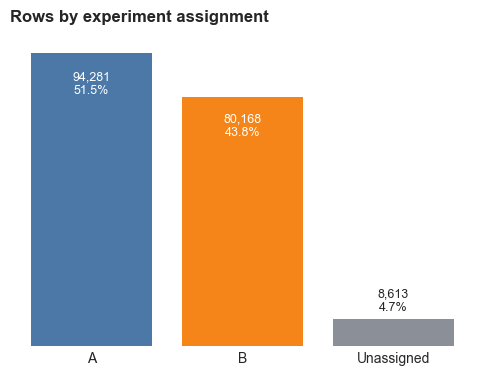

In [105]:
helpers.plot_row_coverage(raw_data, ab_data, excluded_data)
helpers.plt.show()


- Usable for A/B: 95.3% of rows are assigned to A or B.
- Unassigned: 8,613 rows (4.7%); exclude from A-vs-B unless the experiment design says otherwise.
- Real-world follow-up: verify the assignment and exclusion rules before interpreting outcomes.

Next, check lead-event coverage. The chart compares each channel with the combined `any lead` KPI.

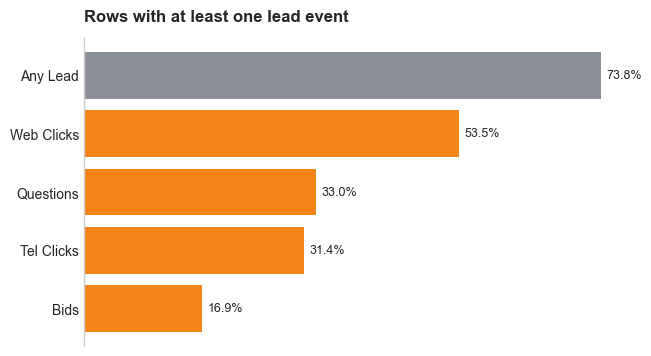

In [106]:
helpers.plot_lead_channel_coverage(raw_data)
helpers.plt.show()


- The chart shows each lead channel is much smaller than `Any Lead`.
- This supports using the combined KPI as the primary metric.
- Later checks still show lead volume by channel.

- Lead metrics have very few missing values and no negative values.
- Some undocumented fields are useful for balance and segment checks.
- `l2` is excluded because its meaning is unclear.

### Duplicated Ad IDs

There are 5 duplicated `src_ad_id` values, covering 10 rows.

In [107]:
display(helpers.style_table(helpers.duplicated_ad_id_rows(raw_data)))

,Ad ID,Tel Clicks,Bids,Body Type,Photos,Doors,Questions,Build Year,Emissions,Energy Label,Brand,Start Date,Power,Web Clicks,Model,Seats,Price,Test Group
0,1011548826,0,0,MPV,18,5,0,2003,152,D,RENAULT,2016-11-25,59,1,Scenic,5,"22,500",A
1,1011548826,0,0,Hatchback (3/5-deurs),14,4,0,2005,169,C,CITROEN,2016-11-25,80,0,C4,5,"52,500",B
2,1027581466,0,0,Hatchback (3/5-deurs),13,5,0,2010,0,NaN,SEAT,2016-11-06,118,2,Leon,5,"117,500",A
3,1027581466,0,0,MPV,24,4,0,2008,155,C,MERCEDES,2016-11-06,70,0,A-Klasse,5,"79,500",B
4,1045227572,0,0,Hatchback (3/5-deurs),24,5,0,2012,134,C,OPEL,2016-11-26,74,0,CORSA,5,"89,500",A
5,1045227572,0,0,Terreinwagen,24,5,0,2013,168,D,MINI,2016-11-26,90,1,Countryman,5,"269,500",B
6,1054003502,0,0,Stationwagon,24,5,0,2005,235,F,SAAB,2016-11-19,154,2,3-Sep,5,"64,000",A
7,1054003502,1,0,Sedan (2/4-deurs),11,4,0,2006,186,C,AUDI,2016-11-19,103,2,A6,5,"73,900",A
8,1072325510,0,0,Hatchback (3/5-deurs),12,3,0,2013,92,A,FIAT,2016-11-07,63,0,500,4,"99,450",A
9,1072325510,0,0,Cabriolet,24,2,0,2000,294,NaN,CHEVROLET,2016-11-07,142,3,Camaro,4,"119,000",B


In [108]:
display(helpers.style_table(helpers.duplicated_ad_id_differences(raw_data)))

,Ad ID,Rows,Groups Seen,Varying Columns
0,1011548826,2,"A, B","carrosserie, photo_cnt, aantaldeuren, bouwjaar, emissie, energielabel, brand, vermogen, webclicks, model, price, group"
1,1027581466,2,"A, B","carrosserie, photo_cnt, aantaldeuren, bouwjaar, emissie, energielabel, brand, vermogen, webclicks, model, price, group"
2,1045227572,2,"A, B","carrosserie, bouwjaar, emissie, energielabel, brand, vermogen, webclicks, model, price, group"
3,1054003502,2,A,"telclicks, carrosserie, photo_cnt, aantaldeuren, bouwjaar, emissie, energielabel, brand, vermogen, model, price"
4,1072325510,2,"A, B","carrosserie, photo_cnt, aantaldeuren, bouwjaar, emissie, energielabel, brand, vermogen, webclicks, model, price, group"


The paired duplicate-ID rows differ on car attributes. I keep them in the primary analysis because they are only 10 rows, then test sensitivity later by excluding them.

## 3. Group Assignment Check

- Raw groups: A, B, and Unassigned.
- A/B imbalance has negligible power impact at this sample size.
- Real-world follow-up: sample-ratio check if 50/50 was expected.

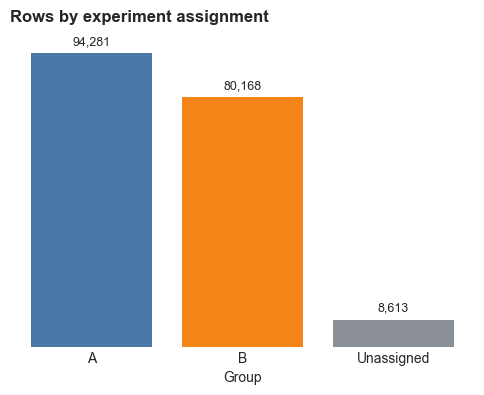

In [109]:
helpers.plot_group_sizes(raw_data)
helpers.plt.show()


## 4. Balance Check

- B differs from A on key car/ad dimensions.
- Largest gaps: price, car age, and mileage.
- This matters for causal interpretation: part of the lead-rate gap could reflect group mix, not only the product change.

In [110]:
display(helpers.style_table(helpers.numeric_balance_summary(ab_data)))

group,Dimension,A,B,Diff B-A,% Diff
0,Price,"106,457.104","95,563.256","-10,893.849",-0.102
1,Mileage,"140,764.544","149,516.859","8,752.315",0.062
2,Days Live,27.624,27.646,0.022,0.001
3,Photos,15.742,15.366,-0.376,-0.024
4,Build Year,2007.560,2006.721,-0.839,-0.000
5,Doors,4.270,4.220,-0.049,-0.012
6,Seats,4.735,4.747,0.012,0.002
7,Emissions,129.123,129.950,0.827,0.006
8,Power,85.787,85.420,-0.367,-0.004
9,Car Age,8.440,9.279,0.839,0.099


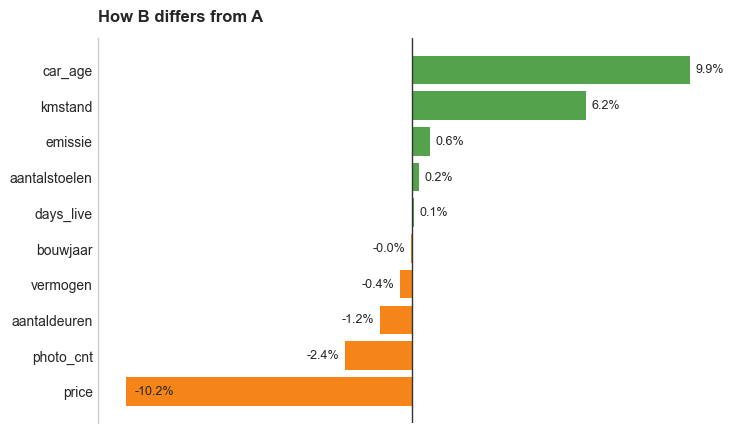

In [111]:
helpers.plot_numeric_balance(ab_data)
helpers.plt.show()


## 5. Primary Result

- Treatment group B has a 74.8% lead rate vs 72.8% for control group A.
- Difference: +2.0 percentage points.
- Result is statistically significant (p < 0.001).
- Causal readout still depends on assignment quality and balance checks.

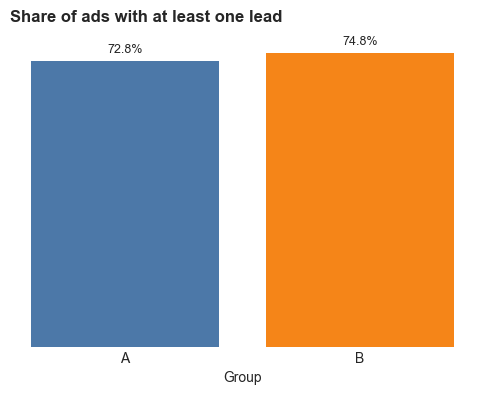

In [112]:
outcomes = helpers.lead_outcome_summary(ab_data)

helpers.plot_lead_rate(outcomes)
helpers.plt.show()


### Statistical Inference

- The chart shows the primary KPI directly.
- The table below focuses on lift and statistical inference.
- Absolute lift: B minus A, in percentage points.
- Relative lift: absolute lift divided by A lead rate.

In [113]:
display(helpers.lift_summary_table(ab_data).style.hide(axis="index"))


Metric,Value
Absolute lead-rate lift,2.0 pp
95% CI for absolute lift,1.6 to 2.4 pp
Relative lift vs A,2.8%
p-value,<0.001
Significance level,5%
Approx. power for observed effect,>99.9%


Key terms:

- Significance level: threshold for treating the gap as unlikely to be random noise.
- Statistical power: chance of detecting a real effect of this size.

## 6. Lead Volume Checks

- B also has higher average lead volume per ad.
- Channel checks show whether the lift is broad or concentrated in one lead type.

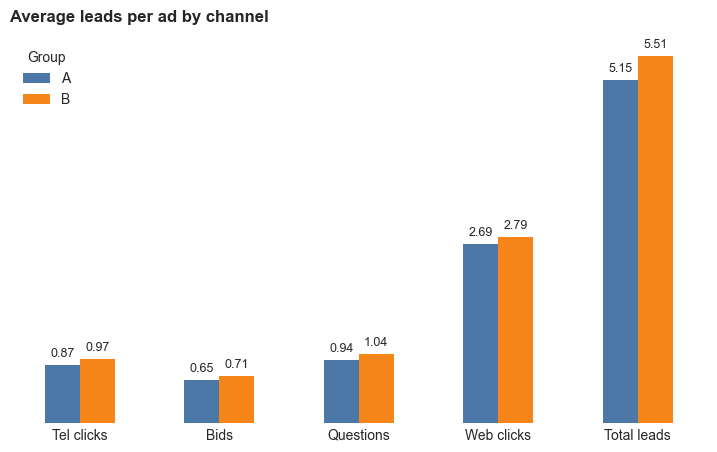

In [114]:
helpers.plot_average_leads_by_channel(outcomes)
helpers.plt.show()


- B is higher on every lead channel and total leads per ad.
- Gaps are broad, but small by channel.

## 7. Robustness Check

Purpose: verify that the duplicate-ID issue found during data readiness does not drive the primary conclusion.

In [115]:
display(helpers.style_table(helpers.duplicate_id_sensitivity(ab_data)))

,Metric,With Dup IDs,Excl Dup IDs
0,Rows,"174,449","174,439"
1,Rows Dropped,0,10
2,% Rows Dropped,0,0.000
3,A Lead Rate,0.728,0.728
4,B Lead Rate,0.748,0.748
5,Abs Lead-Rate Lift,0.020,0.020
6,Relative Lift vs A,0.028,0.028


Excluding duplicated `src_ad_id` rows does not materially change the A/B lead-rate comparison. The result is robust to this specific data-quality issue.

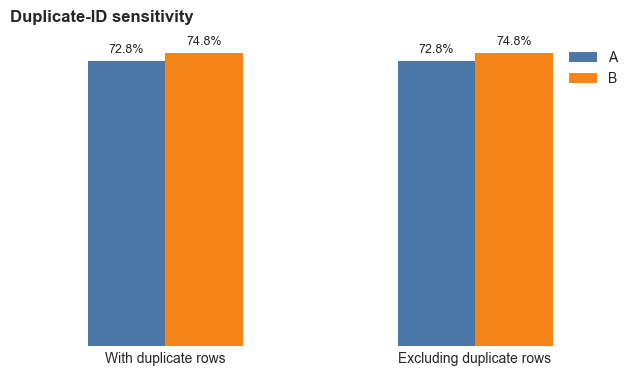

In [116]:
helpers.plot_duplicate_id_sensitivity(ab_data)
helpers.plt.show()


Removing duplicated ad IDs leaves the A and B lead rates essentially unchanged. The duplicate-ID issue is worth documenting, but it does not drive the main result.

## 8. Business Conclusion and Recommendation

- Treatment group B is directionally positive.
- B has more ads with leads and more total leads per ad.
- The B-A lead-rate gap is statistically significant (p < 0.001).

In [ ]:
helpers.print_business_insights(ab_data)

The headline business result is positive for B. In a real-world setting, the rollout recommendation would depend on validating the test setup. The KPI chart below keeps the final answer anchored in the two headline comparisons: lead rate and average total leads.

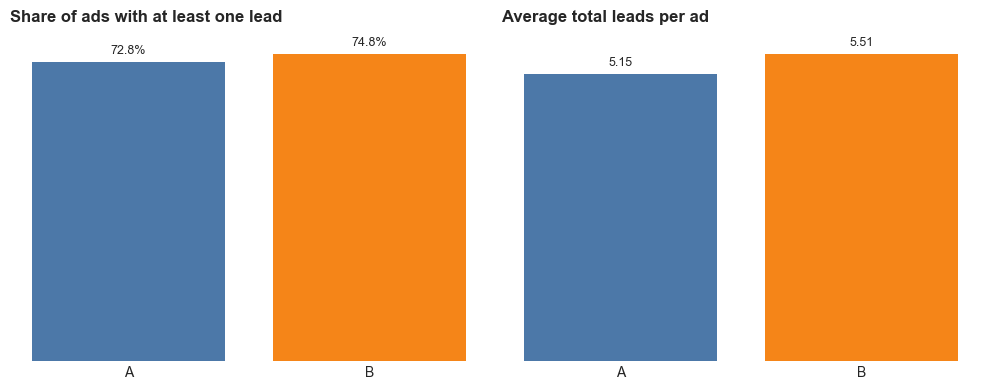

In [118]:
helpers.plot_final_summary(outcomes)
helpers.plt.show()


- Treatment group B performed better than control group A.
- The lead-rate gap is statistically significant.
- Not final causal proof yet: B differs from A on several car dimensions.
- Real-world decision: validate setup before rollout.